In [1]:
print('aa')

aa


In [2]:
import matplotlib.pyplot as plt
from scapy.all import rdpcap
from datetime import datetime, timedelta
import numpy as np

# Function to classify packet types
def classify_packet(packet):
    if packet.haslayer("ARP"):
        return "ARP"
    elif packet.haslayer("ICMP"):
        return "ICMP"
    elif packet.haslayer("TCP"):
        return "TCP"
    elif packet.haslayer("UDP"):
        return "UDP"
    else:
        return "Other"

# Function to process packets and count types
def process_pcap(file_path):
    packets = rdpcap(file_path)
    packet_counts = {}

    for packet in packets:
        packet_type = classify_packet(packet)
        if packet_type in packet_counts:
            packet_counts[packet_type] += 1
        else:
            packet_counts[packet_type] = 1

    return packet_counts

# Function to process packets and extract timestamps by type
def process_pcap_by_time(file_path):
    packets = rdpcap(file_path)
    packet_times = {}

    for packet in packets:
        packet_type = classify_packet(packet)
        packet_time = datetime.fromtimestamp(float(packet.time))

        if packet_type not in packet_times:
            packet_times[packet_type] = []

        packet_times[packet_type].append(packet_time)

    return packet_times

# Plot packet type distribution
def plot_packet_types(packet_counts, title):
    plt.bar(packet_counts.keys(), packet_counts.values())
    plt.title(title)
    plt.xlabel("Packet Type")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot packet types over time with binning
def plot_packet_types_binned_by_time(packet_times, bin_size, title):
    plt.figure(figsize=(10, 6))

    for packet_type, times in packet_times.items():
        if packet_type in ["UDP", "Other"]:
            continue

        # Convert times to seconds and create bins
        min_time = min(times)
        max_time = max(times)
        bins = np.arange(min_time, max_time + timedelta(seconds=bin_size), timedelta(seconds=bin_size)).astype(datetime)

        # Count packets in each bin
        binned_counts, _ = np.histogram(times, bins=bins)
        bin_centers = [min_time + timedelta(seconds=i * bin_size) for i in range(len(binned_counts))]

        # Plot the counts over time
        plt.plot(bin_centers, binned_counts, label=packet_type)

    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Packet Count")
    plt.legend()
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()


In [3]:
import seaborn as sns

sns.set_theme(style="whitegrid")
def plot_all_three_subplots(packet_times1, packet_times2, packet_times3, bin_size=5,
                            titles=("Targeted PLC (PLC2)", "Malicious Attacker Component", "Scada")):
    """
    Plots three packet-time distributions (for PLC, Attacker, Scada)
    in a single figure with three vertically stacked subplots,
    sharing the same X (time) and Y (packet count) axes.

    :param packet_times1: dict of packet_type -> list of datetime timestamps
    :param packet_times2: dict of packet_type -> list of datetime timestamps
    :param packet_times3: dict of packet_type -> list of datetime timestamps
    :param bin_size: bin size in seconds
    :param titles: tuple/list of strings for subplot titles
    """

    # Gather all timestamps in one list to determine global min and max
    all_times = []
    for pt_dict in [packet_times1, packet_times2, packet_times3]:
        for times in pt_dict.values():
            all_times.extend(times)

    if not all_times:
        print("No packet timestamps found.")
        return

    global_min_time = min(all_times)
    global_max_time = max(all_times)

    # Create global bins (from min to max time)
    bins = np.arange(global_min_time,
                     global_max_time + timedelta(seconds=bin_size),
                     timedelta(seconds=bin_size)).astype(datetime)

    fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(6, 6))

    # Helper function to plot a single dataset on a given axis
    def plot_binned_times(ax, packet_times, title):
        for packet_type, times in packet_times.items():
            # Histogram the times into the same global bins
            binned_counts, _ = np.histogram(times, bins=bins)
            # We'll use the left edges, plus half bin_size for midpoint
            bin_centers = [bin + timedelta(seconds=bin_size / 2) for bin in bins[:-1]]

            # ARP packets get a marker; others do not
            if packet_type == "ARP":
                ax.plot(bin_centers, binned_counts, label=packet_type, linestyle='-',linewidth=3)
            if packet_type == "TCP":
                ax.plot(bin_centers, binned_counts, label=packet_type, linestyle='-')

        ax.set_title(title)
        ax.set_ylabel("Packet Count")
        ax.legend()

    # Plot each dataset in its respective subplot
    plot_binned_times(axes[0], packet_times1, titles[0])
    plot_binned_times(axes[1], packet_times2, titles[1])
    plot_binned_times(axes[2], packet_times3, titles[2])

    # Only the bottom plot needs an X label
    axes[2].set_xlabel("Time")
    #xticks should not appear
    axes[0].set_xticks([])

    # Auto-format the x-axis dates
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig('output/PLCCase2/CyberLayer.png')

    plt.show()

In [46]:
file_path = '../examples/MiniAnyTownForPaper/Final/ScadaDoS2/DoS_PLC4_ScadaC/PLC2-eth0.pcap'
file_path2 = '../examples/MiniAnyTownForPaper/Final/ScadaDoS2/DoS_PLC4_ScadaC/plc2Attac-eth0.pcap'
file_path3 = '../examples/MiniAnyTownForPaper/Final/ScadaDoS2/DoS_PLC4_ScadaC/scada-eth0.pcap'


packet_times1 = process_pcap_by_time(file_path)
packet_times2 = process_pcap_by_time(file_path2)
packet_times3 = process_pcap_by_time(file_path3)

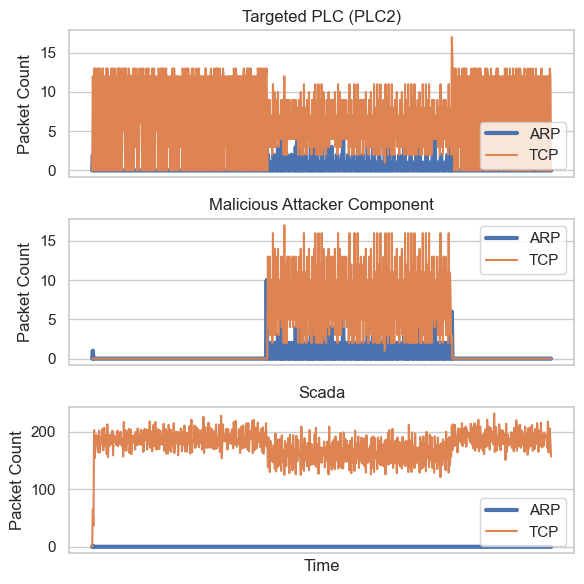

In [94]:


plot_all_three_subplots(packet_times1, packet_times2, packet_times3, bin_size=5)


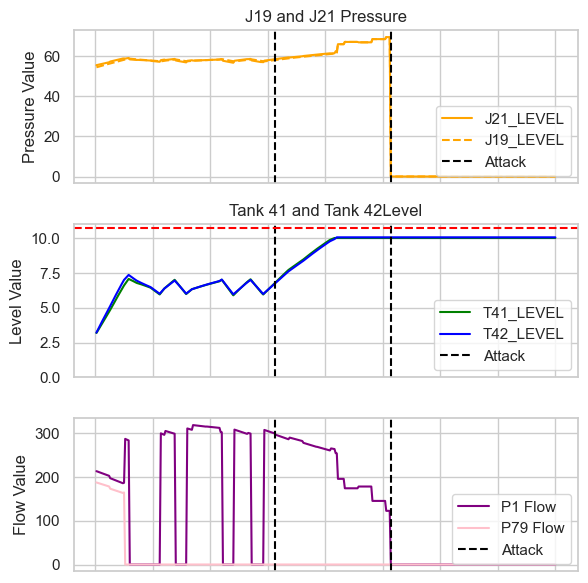

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def find_attack_intervals(data, flag_column):
    """
    Finds the start and end iterations of attacks based on the flag column.
    The attack starts when the flag is 1 and ends when it returns to 0 after 1.

    Parameters:
        data (pd.DataFrame): The DataFrame containing the data.
        flag_column (str): The column name with the attack flag.

    Returns:
        list of tuples: A list of (start, end) iteration pairs for each attack.
    """
    attack_intervals = []
    attack_start = None

    for index, flag in enumerate(data[flag_column]):
        if flag == 1 and attack_start is None:
            attack_start = data['iteration'].iloc[index]
        elif flag == 0 and attack_start is not None:
            attack_end = data['iteration'].iloc[index]
            attack_intervals.append((attack_start, attack_end))
            attack_start = None

    return attack_intervals

# Identify attack intervals in the ground_truth DataFrame




# Load CSV files
ground_truth_df = pd.read_csv('../examples/MiniAnyTownForPaper/Final/LocalPLCDef/DoS_PLC4_PLCC/ground_truth.csv')
scada_df = pd.read_csv('../examples/MiniAnyTownForPaper/Final/LocalPLCDef/DoS_PLC4_PLCC/scada_values.csv')

# Drop the first row
ground_truth_df = ground_truth_df.drop(0)

attack_intervals = find_attack_intervals(ground_truth_df, 'plc4AttackerUnit')
# Define attack start and end iterations (replace with your actual values)
attack_start, attack_end = attack_intervals[0]   # Example iteration when the attack ends

# Create a figure with three mini subplots
fig, axes = plt.subplots(3, 1, figsize=(6, 6), gridspec_kw={'height_ratios': [1, 1, 1]})

# First subplot: Flow
axes[0].plot(ground_truth_df['iteration'], ground_truth_df['J21_LEVEL'], label='J21_LEVEL', color='orange')
axes[0].plot(ground_truth_df['iteration'], ground_truth_df['J19_LEVEL'], label='J19_LEVEL', color='orange', linestyle='--')
axes[0].axvline(x=attack_start, color='black', linestyle='--', label='Attack')
axes[0].axvline(x=attack_end, color='black', linestyle='--', label='')
axes[0].set_title("J19 and J21 Pressure")
axes[0].set_ylabel("Pressure Value")
axes[0].legend(loc='lower right')

# Second subplot: Tank Level (T41_LEVEL)
axes[1].plot(ground_truth_df['iteration'], ground_truth_df['T41_LEVEL'], label='T41_LEVEL', color='green')
axes[1].plot(ground_truth_df['iteration'], ground_truth_df['T42_LEVEL'], label='T42_LEVEL', color='blue')
axes[1].axvline(x=attack_start, color='black', linestyle='--', label='Attack')
axes[1].axvline(x=attack_end, color='black', linestyle='--', label='')
axes[1].set_title("Tank 41 and Tank 42Level")
axes[1].set_ylabel("Level Value")
#set ylim 0 to 10.7
axes[1].set_ylim(0, 11)
#make horizontal line at 10.7
axes[1].axhline(y=10.7, color='red', linestyle='--', label='')
axes[1].legend(loc='lower right')

# Third subplot: Tank Level (T41MiM)
axes[2].plot(ground_truth_df['iteration'], ground_truth_df['P1_FLOW'], label='P1 Flow', color='purple')
axes[2].plot(ground_truth_df['iteration'], ground_truth_df['P79_FLOW'], label='P79 Flow', color='pink')
axes[2].axvline(x=attack_start, color='black', linestyle='--', label='Attack')
axes[2].axvline(x=attack_end, color='black', linestyle='--', label='')
axes[2].set_ylabel("Flow Value")
axes[2].legend(loc='lower right')


# Hide x-ticks for all subplots
for ax in axes:
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# Adjust layout for better spacing
plt.tight_layout()

# Save the plot
plt.savefig('output/PLCCase1/PhysicalLayerGround.png')

# Display the plots
plt.show()


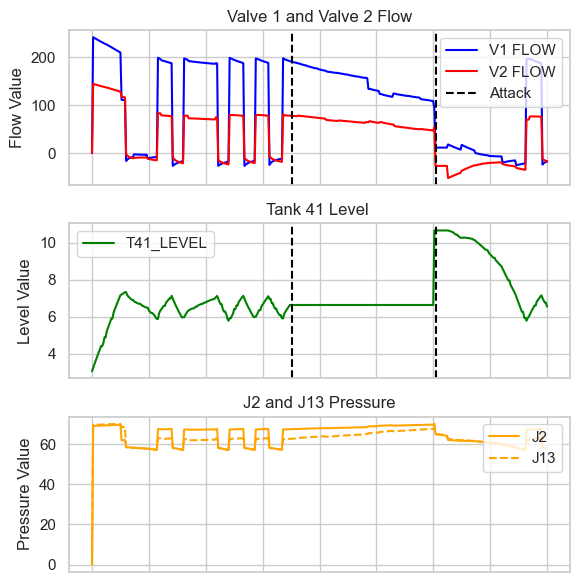

In [92]:
#under ground_truth_df
##################################
# NEW two-subplot figure for V1_FLOW and V2_FLOW
##################################
fig2, axes2 = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

# First subplot: Flow
axes2[0].plot(scada_df['iteration'], scada_df['V1F'], label='V1 FLOW', color='blue')
axes2[0].plot(scada_df['iteration'], scada_df['V2F'], label='V2 FLOW', color='red')
axes2[0].axvline(x=attack_start, color='black', linestyle='--', label='Attack')
axes2[0].axvline(x=attack_end, color='black', linestyle='--', label='')
axes2[0].set_title("Valve 1 and Valve 2 Flow")
axes2[0].set_ylabel("Flow Value")
axes2[0].legend(loc='upper right')


# Second subplot: Tank Level (T41_LEVEL)


#make every 10 values the series values of 69-79

axes2[1].plot(scada_df['iteration'], scada_df['T41'], label='T41_LEVEL', color='green')
axes2[1].set_title("Tank 41 Level ")
axes2[1].set_ylabel("Level Value")
axes2[1].legend()
axes2[1].axvline(x=attack_start, color='black', linestyle='--', label='Attack')
axes2[1].axvline(x=attack_end, color='black', linestyle='--', label='')


axes2[2].plot(scada_df['iteration'], scada_df['J2'], label='J2', color='orange')
axes2[2].plot(scada_df['iteration'], scada_df['J13'], label='J13', color='orange',linestyle='--')

axes2[2].set_title("J2 and J13 Pressure")
axes2[2].set_ylabel("Pressure Value")
axes2[2].legend(loc='upper right')



# Hide x-ticks for all subplots
for ax in axes2:
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)


# Adjust layout for better spacing
plt.tight_layout()
plt.savefig('output/ScadaCase2/ScadaLayer.png')
plt.show()